# IIA - Trabajo Práctico 3 - Redes Neuronales

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sklearn as skl
from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, zero_one_loss

from copy import deepcopy

#Importe para las espirales
from typing import Tuple

# Explorando las Redes

In [2]:
# Parámetros
"""
Comenzar y frenar el entrenamiento de una red es costoso, por lo que no
mediremos las métricas una vez por época, sino que haremos varias épocas a la
vez. Por ésto definimos sub-épocas, por ejemplo como 10, para realizar 10 épocas
a la vez y luego medir las métricas de error.
"""
sub_epocas = 25   # numero de epocas que entrena cada vez
super_epocas = 100 # numero de veces que realizaremos sub-epocas
# epocas ~= sub_epocas * super_epocas
eta = 0.01        # learning rate
alfa = 0.9        # momentum
N2 = 60            # neuronas en la capa oculta

## Definimos nuestras redes


In [3]:
# Defino MLP para regresión
regr = MLPRegressor(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)

print(regr)

MLPRegressor(activation='logistic', alpha=0.0, batch_size=1,
             hidden_layer_sizes=(60,), learning_rate_init=0.01, max_iter=25,
             nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)


In [4]:
# Defino MLP para clasificación
clasif = MLPClassifier(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)

print(clasif)

MLPClassifier(activation='logistic', alpha=0.0, batch_size=1,
              hidden_layer_sizes=(60,), learning_rate_init=0.01, max_iter=25,
              nesterovs_momentum=False, solver='sgd', tol=0.0, warm_start=True)


## Entrenamos

> **Warning**: el entrenamiento de las redes es computacionalmente pesado. Algunos de los entrenamientos que se plantean en el trabajo llevan varios minutos, dependiendo de la velocidad del procesador. El tiempo máximo en Google Colab fue de alrededor de 10 minutos. Tengan eso en cuenta para hacer el trabajo.



In [5]:
def cargar_csv(path, xcols=2):
    """
    Argumentos:
      path (str): ruta al archivo csv a cargar
      xcols (int): cantidad de columnas que representan las entradas,
        la columna restante representara la clase o dato de salida
    """
    df = pd.read_csv(path, header=None)
    X = df.loc[:, 0:(xcols-1)]
    y = df.loc[:, xcols]
    return X,y

In [6]:
def entrenar_red(red, evaluaciones,
                 X_train, y_train,
                 X_val,   y_val,
                 X_test,  y_test):
    """
    Función que entrena una red ya definida previamente "evaluaciones" veces,
    cada vez entrenando un número de épocas elegido al crear la red y midiendo
    el error en train, validación y test al terminar ese paso de entrenamiento.
    Guarda y devuelve la red en el paso de evaluación que da el mínimo error de
    validación.

    Argumentos:
      red: red neuronal predefinida
      evaluaciones (int): las veces que evalua
      X_{}: los conjuntos de valores de entrada de train, validación y test
      y_{}: los conjuntos de valores de salida o clase

    Salidas:
      best_red: la red entrenada en el mínimo de validación
      error_{}: los errores de: train, validación y test medidos en cada
        evaluación
    """
    error_train = []
    error_val = []
    error_test = []
    best_val = 1.0
    best_red = red
    best_err_test = 1.0
    for epoch in range(evaluaciones):
      # red.partial_fit(X_train, y_train, classes=[0,1])
      ## Podríamos llamar partial_fit para realizar una sóla pasada a la vez,
      ## pero al ser muy costoso frenar y reanudar el entrenamiento realizamos
      ## varias épocas a la vez. Recordemos que la red fue definida con el
      ## parámetro 'sub-epocas', con lo cual cada llamado a 'fit' realiza esa
      ## cantidad de épocas
      red.fit(X_train, y_train)
      # error de training
      y_pred_train = red.predict(X_train)
      error_train.append(zero_one_loss(y_train, y_pred_train))
      # error de validacion
      y_pred_val = red.predict(X_val)
      cur_val = zero_one_loss(y_val, y_pred_val)
      error_val.append(cur_val)
      # error de test
      error_test.append(1 - red.score(X_test, y_test))
      if best_val > cur_val:
        best_val = cur_val
        best_red = deepcopy(red)
        # ACTUALIZACION PARA EJERCICIO 2: Necesitamos devolver el mejor error de test,
        # el cual es el de la mejor red (es decir, la red antes de que empiece a hacer overfitting)
        best_err_test = error_test[-1] # devolvemos el último
    return best_red, error_train, error_val, error_test, best_err_test

In [ ]:
# Cargamos los datos...
X, y = cargar_csv('xor.csv')

# Hacemos el split de training y testing
X2, X_test, y2, y_test = skl.model_selection.train_test_split(
    X, y, test_size=0.2)  # para xor de 200 me quedan 40 de test

# y spliteamos el training en training y validacion
X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(
    X2, y2, test_size=0.2)  # para xor de 160 me quedan 32 de val

# Corremos el entrenamiento
clasif, e_train, e_val, e_test, e_bestErr = entrenar_red(
    clasif, super_epocas, X_train, y_train, X_val, y_val, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py

## Ploteamos Algunas Métricas

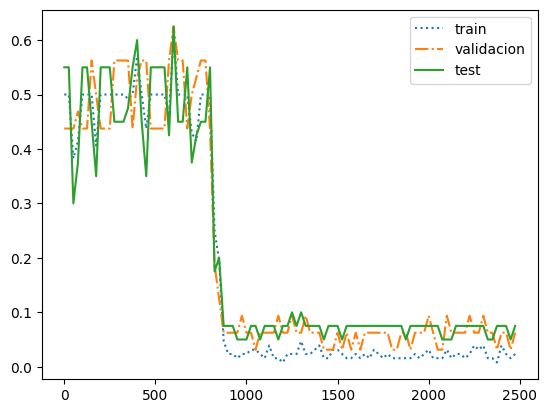

In [ ]:
rango = np.array(range(super_epocas)) * sub_epocas
plt.plot(rango, e_train, label="train", linestyle=":")
plt.plot(rango, e_val, label="validacion", linestyle="-.")
plt.plot(rango, e_test, label="test", linestyle="-")
plt.legend()
plt.show()

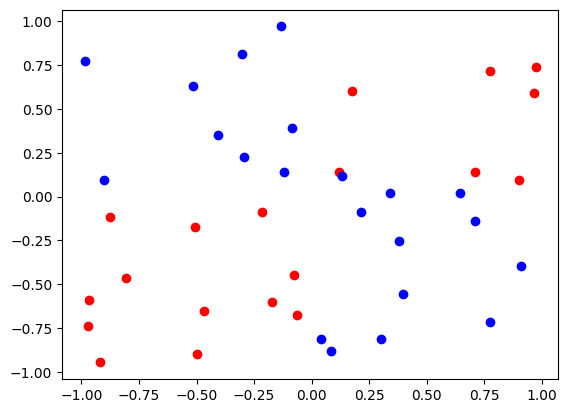

In [ ]:
y_out = clasif.predict(X_test)
X_out = X_test.copy()
X_out[2] = y_out

# diferenciar entre clase 0 y clase 1
c0 = X_out.loc[X_out[2] == 0]
c1 = X_out.loc[X_out[2] == 1]

xs0 = c0[0].values.tolist()
ys0 = c0[1].values.tolist()

xs1 = c1[0].values.tolist()
ys1 = c1[1].values.tolist()

plt.scatter(xs0, ys0, color='red')
plt.scatter(xs1, ys1, color='blue')
plt.show()

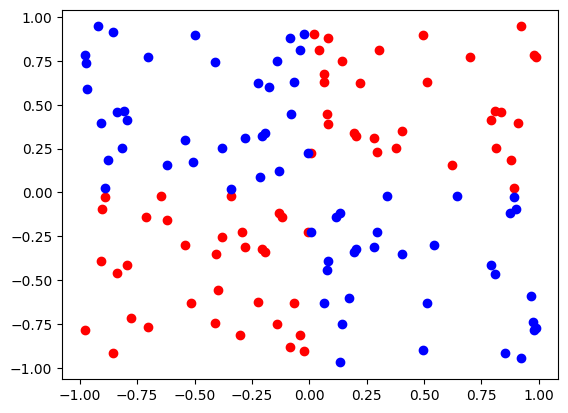

In [ ]:
# diferenciar entre clase 0 y clase 1
Xt = X_train.copy()
Xt[2] = y_train
c0 = Xt.loc[Xt[2] == 0]
c1 = Xt.loc[Xt[2] == 1]

xs0 = c0[0].values.tolist()
ys0 = c0[1].values.tolist()

xs1 = c1[0].values.tolist()
ys1 = c1[1].values.tolist()

plt.scatter(xs0, ys0, color='red')
plt.scatter(xs1, ys1, color='blue')
plt.show()

# Ejercicio 1. Capacidad de Modelado.

Traemos la función de espirales del TP0.

In [26]:
def espirales(n: int) -> Tuple[np.ndarray, np.ndarray]:
    half = n // 2
    X0, X1 = [], []

    while len(X0) < half or len(X1) < half:
        x = np.random.uniform(-1, 1)
        yc = np.random.uniform(-1, 1)

        r = np.sqrt(x**2 + yc**2)
        if r > 1 or r == 0:
            continue

        # theta base en [0, 2*pi)
        theta = np.arctan2(yc, x) % (2 * np.pi)

        # Probamos theta y theta + 2*pi (segunda vuelta)
        # En cuál de las dos vueltas cae el punto según su r
        in_band = False
        for k in range(-1,3):  # hasta 3 vueltas
            t = theta + 2 * np.pi * k
            rho_low  = t / (4 * np.pi)
            rho_high = (t + np.pi) / (4 * np.pi)
            if rho_low <= r <= rho_high:
                in_band = True
                break

        label = 0 if in_band else 1

        if label == 0 and len(X0) < half:
            X0.append([x, yc])
        elif label == 1 and len(X1) < half:
            X1.append([x, yc])

    X = np.array(X0 + X1)
    y = np.hstack([np.zeros(half), np.ones(half)])
    return X, y


Ahora definimos algunas redes

In [ ]:
red1 = MLPClassifier(
    hidden_layer_sizes=(2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=0.1,
    momentum=0.9, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=20
)

red2 = MLPClassifier(
    hidden_layer_sizes=(10,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=0.1,
    momentum=0.9, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=20
)

red3 = MLPClassifier(
    hidden_layer_sizes=(20,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=0.1,
    momentum=0.9, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=20
)

red4 = MLPClassifier(
    hidden_layer_sizes=(40,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=0.1,
    momentum=0.9, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=20
)

#Generamos el conjunto de datos, de los cuales usaremos 600 para ajustar la red, y 2000 para test.
XTot, YTot = espirales(2600)

# Dividimos, primero para los 600 de train y luego para los de validación
X_trainOrig, X_test, y_trainOrig, y_test = skl.model_selection.train_test_split(
    XTot, YTot, test_size=2000) # si test size es int, toma esa cantidad

X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(
    X_trainOrig, y_trainOrig, test_size=0.2) # si test size es float, entonces debe ser entre 0 y 1, y toma ese porcentaje

cl1, e1_train, e1_val, e1_test, e1_bestErr = entrenar_red(red1, 1000, X_train, y_train, X_val, y_val, X_test, y_test)

cl2, e2_train, e2_val, e2_test, e2_bestErr = entrenar_red(red2, 1000, X_train, y_train, X_val, y_val, X_test, y_test)

cl3, e3_train, e3_val, e3_test, e3_bestErr = entrenar_red(red3, 1000, X_train, y_train, X_val, y_val, X_test, y_test)

cl4, e4_train, e4_val, e4_test, e4_bestErr = entrenar_red(red4, 1000, X_train, y_train, X_val, y_val, X_test, y_test)



Subimos las redes a un archivo para no perderlas

In [21]:
#IMPORTANTE: Este import es para guardar las redes ya entrenadas, y no perderlas en caso
# de que se pierda el entorno. A la hora de corregir capaz vean mejor comentar estos importes

from google.colab import drive
drive.mount('/content/drive')

import os
import joblib

ruta_guardado = '/content/drive/MyDrive/Redes_TP3'

os.makedirs(ruta_guardado, exist_ok=True)

ruta_archivo = os.path.join(ruta_guardado, 'mejores_redes.pkl')

ModuleNotFoundError: No module named 'google'

In [ ]:
datos_completos = {
    '2_neuronas': {
        'modelo': cl1,
        'errores_train': e1_train,
        'errores_val': e1_val,
        'errores_test': e1_test
    },
    '10_neuronas': {
        'modelo': cl2,
        'errores_train': e2_train,
        'errores_val': e2_val,
        'errores_test': e2_test
    },
    '20_neuronas': {
        'modelo': cl3,
        'errores_train': e3_train,
        'errores_val': e3_val,
        'errores_test': e3_test
    },
    '40_neuronas': {
        'modelo': cl4,
        'errores_train': e4_train,
        'errores_val': e4_val,
        'errores_test': e4_test
    }
}

joblib.dump(datos_completos, ruta_archivo)

print("Redes guardadas exitosamente en:", ruta_archivo)

NameError: name 'e1_train' is not defined

Carga de redes si se reinició la sesión

In [22]:
import joblib

datos_cargados = joblib.load('mejores_redes.pkl')

cl1 = datos_cargados['2_neuronas']['modelo']
cl2 = datos_cargados['10_neuronas']['modelo']
cl3 = datos_cargados['20_neuronas']['modelo']
cl4 = datos_cargados['40_neuronas']['modelo']



c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelBinarizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MLPClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Mostrando resultados

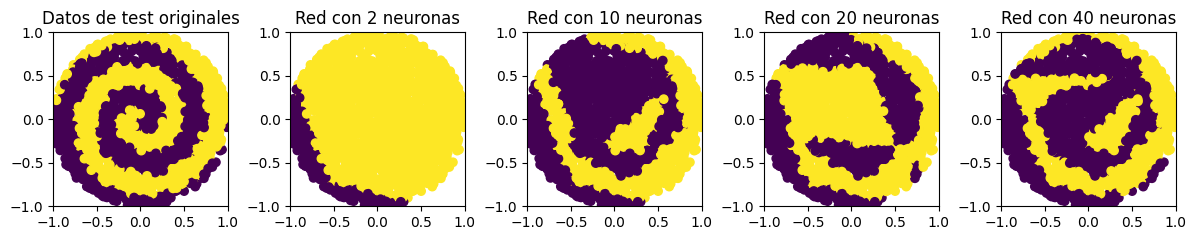

In [28]:
y1_out = cl1.predict(X_test)
y2_out = cl2.predict(X_test)
y3_out = cl3.predict(X_test)
y4_out = cl4.predict(X_test)


fig, axes = plt.subplots(1, 5, figsize=(12, 5))

axes[0].set_title('Datos de test originales')
axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis')

axes[1].set_title('Red con 2 neuronas')
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y1_out, cmap='viridis')

axes[2].set_title('Red con 10 neuronas')
axes[2].scatter(X_test[:, 0], X_test[:, 1], c=y2_out, cmap='viridis')

axes[3].set_title('Red con 20 neuronas')
axes[3].scatter(X_test[:, 0], X_test[:, 1], c=y3_out, cmap='viridis')

axes[4].set_title('Red con 40 neuronas')
axes[4].scatter(X_test[:, 0], X_test[:, 1], c=y4_out, cmap='viridis')


for ax in axes:
    ax.set_aspect('equal')
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)

plt.tight_layout()
plt.show()

#Comentarios
Acá podemos ver como a medida que aumentamos la cantidad de neuronas en la capa oculta, mejor es la aproximación de las espirales. De todas formas, la aproximación es mala, esto puede ser posible ya que nuestra red neuronal tiene una sola capa intermedia (FALTA COMPLETAR)

# Ejercicio 2. Mínimos Locales.

Creando las redes...

In [30]:
#Primero cargamos el csv
X, y = cargar_csv('dos_elipses.data')

# spliteamos los datos de entrenamiento en entrenamiento y validación
X_train, X_val, y_train, y_val = skl.model_selection.train_test_split(
    X, y, test_size=100)

X_test, y_test = cargar_csv('dos_elipses.test')

#Entrenando las redes
COMENTARIO: Lo que nos devuelve la función "entrenar_red" para el valor "e_test" es un vector de los errores que tenía la predicción para cada super-época cuando se entrenó la red. Entonces, a fin de este ejercicio, necesitamos elegir algún error candidato para que aporte al promedio de los 10 entrenamientos aleatorios con los mismos parámetros de la red.

Para esto modificamos la función entrenar_red, de manera que ahora devuelve el error de la mejor red, es decir, la que devuelve como primer argumento dicha función. Esta función es la que se espera que tenga el menor error posible.

Además, se usa la librería joblib para tratar de paralelizar los entrenamientos de redes. Desafortunadamente, la librería sklearn no permite paralelizar el cómputo de entrenamiento dentro de una misma red ni tampoco utilizar la GPU como entorno de ejecución.
Por lo tanto, lo que deberíamos ganar paralelizando es que los 10 entrenamientos para cada combinación de eta y alfa se hagan en paralelo. Digo "deberiamos" ya que si estamos con la versión gratuita de google colab, éste solo nos provee dos cores de CPU, por lo que a lo sumo podemos entrenar dos redes a la vez.

In [ ]:
from joblib import Parallel, delayed

etas = [0.1, 0.01, 0.001]
alfas = [0.0, 0.5, 0.9]

def evaluar_configuracion(e, a, X_train, y_train, X_val, y_val, X_test, y_test):
    errores_repeticiones = []
    for j in range(10):
        red_exp = MLPClassifier(
            hidden_layer_sizes=(6,), activation='logistic', solver='sgd', alpha=0.0,
            batch_size=1, learning_rate='constant', learning_rate_init=e,
            momentum=a, nesterovs_momentum=False, tol=0.0, warm_start=True,
            max_iter=50
        )

        _, _, _, _, best_err_test = entrenar_red(
            red_exp, 300, X_train, y_train, X_val, y_val, X_test, y_test
        )
        errores_repeticiones.append(best_err_test)

    media_error = np.mean(errores_repeticiones)

    return {
        'eta': e,
        'alfa': a,
        'test_error_medio': media_error,
        'porcentaje_de_error': f"{media_error:.2%}"
    }

# Ejecución paralela sobre las combinaciones de eta y alfa
resultados_experimentos = Parallel(n_jobs=-1)(
    delayed(evaluar_configuracion)(e, a, X_train, y_train, X_val, y_val, X_test, y_test)
    for e in etas for a in alfas
)

In [15]:
df_resultados = pd.DataFrame(resultados_experimentos)
display(df_resultados[['eta', 'alfa', 'test_error_medio', 'porcentaje_de_error']])

,eta,alfa,test_error_medio,porcentaje_de_error
0,0.100,0.0,0.08255,8.25%
1,0.100,0.5,0.04840,4.84%
2,0.100,0.9,0.05630,5.63%
3,0.010,0.0,0.22325,22.33%
4,0.010,0.5,0.18500,18.50%
5,0.010,0.9,0.06745,6.74%
6,0.001,0.0,0.24350,24.35%
7,0.001,0.5,0.24350,24.35%
8,0.001,0.9,0.21695,21.70%


Acá notamos como 

Graficamos los errores de test, validación y entrenamiento de la red con los mejores parámetros alfa y eta. Estos son los que minimizan el promedio de los (mejores) errores de test en 10 entrenamientos distintos de una red con dichos parámetros.

c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: Conver

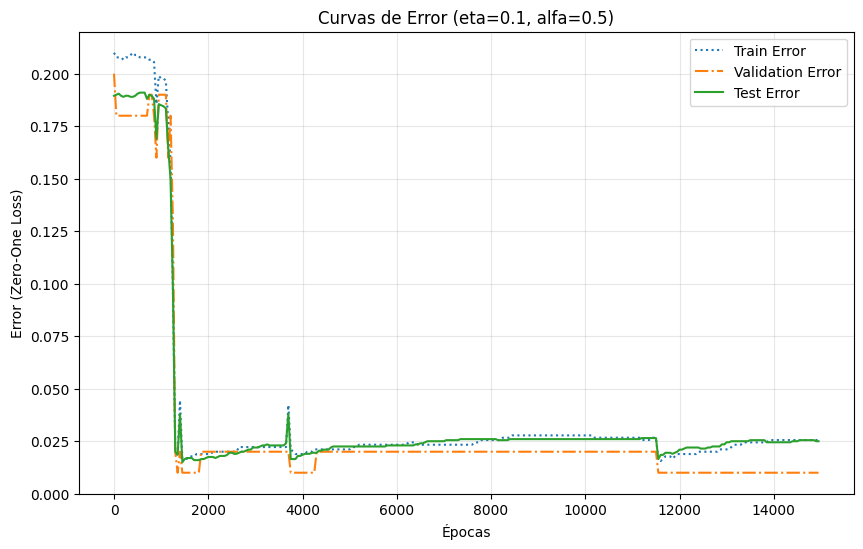

In [32]:
mejor_idx = df_resultados['test_error_medio'].idxmin()
mejor_eta = df_resultados.loc[mejor_idx, 'eta']
mejor_alfa = df_resultados.loc[mejor_idx, 'alfa']

red_mejor = MLPClassifier(
    hidden_layer_sizes=(6,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=mejor_eta,
    momentum=mejor_alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=50, random_state=72 # le agrego para q sea determinista
)

_, e_train, e_val, e_test, _ = entrenar_red(
    red_mejor, 300, X_train, y_train, X_val, y_val, X_test, y_test
)

rango_epocas = np.arange(300) * 50
plt.figure(figsize=(10, 6))
plt.plot(rango_epocas, e_train, label='Train Error', linestyle=':')
plt.plot(rango_epocas, e_val, label='Validation Error', linestyle='-.')
plt.plot(rango_epocas, e_test, label='Test Error', linestyle='-')

plt.title(f'Curvas de Error (eta={mejor_eta}, alfa={mejor_alfa})')
plt.xlabel('Épocas')
plt.ylabel('Error (Zero-One Loss)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
display(df_resultados.sort_values(by='test_error_medio').reset_index(drop=True))

,eta,alfa,test_error_medio,porcentaje_de_error
0,0.100,0.5,0.04840,4.84%
1,0.100,0.9,0.05630,5.63%
2,0.010,0.9,0.06745,6.74%
3,0.100,0.0,0.08255,8.25%
4,0.010,0.5,0.18500,18.50%
5,0.001,0.9,0.21695,21.70%
6,0.010,0.0,0.22325,22.33%
7,0.001,0.0,0.24350,24.35%
8,0.001,0.5,0.24350,24.35%


# Vemos como predice cada red los valores de test

c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\santi\OneDrive\Desktop\Trabajo Práctico 3 - Redes Neuronales\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: Conver

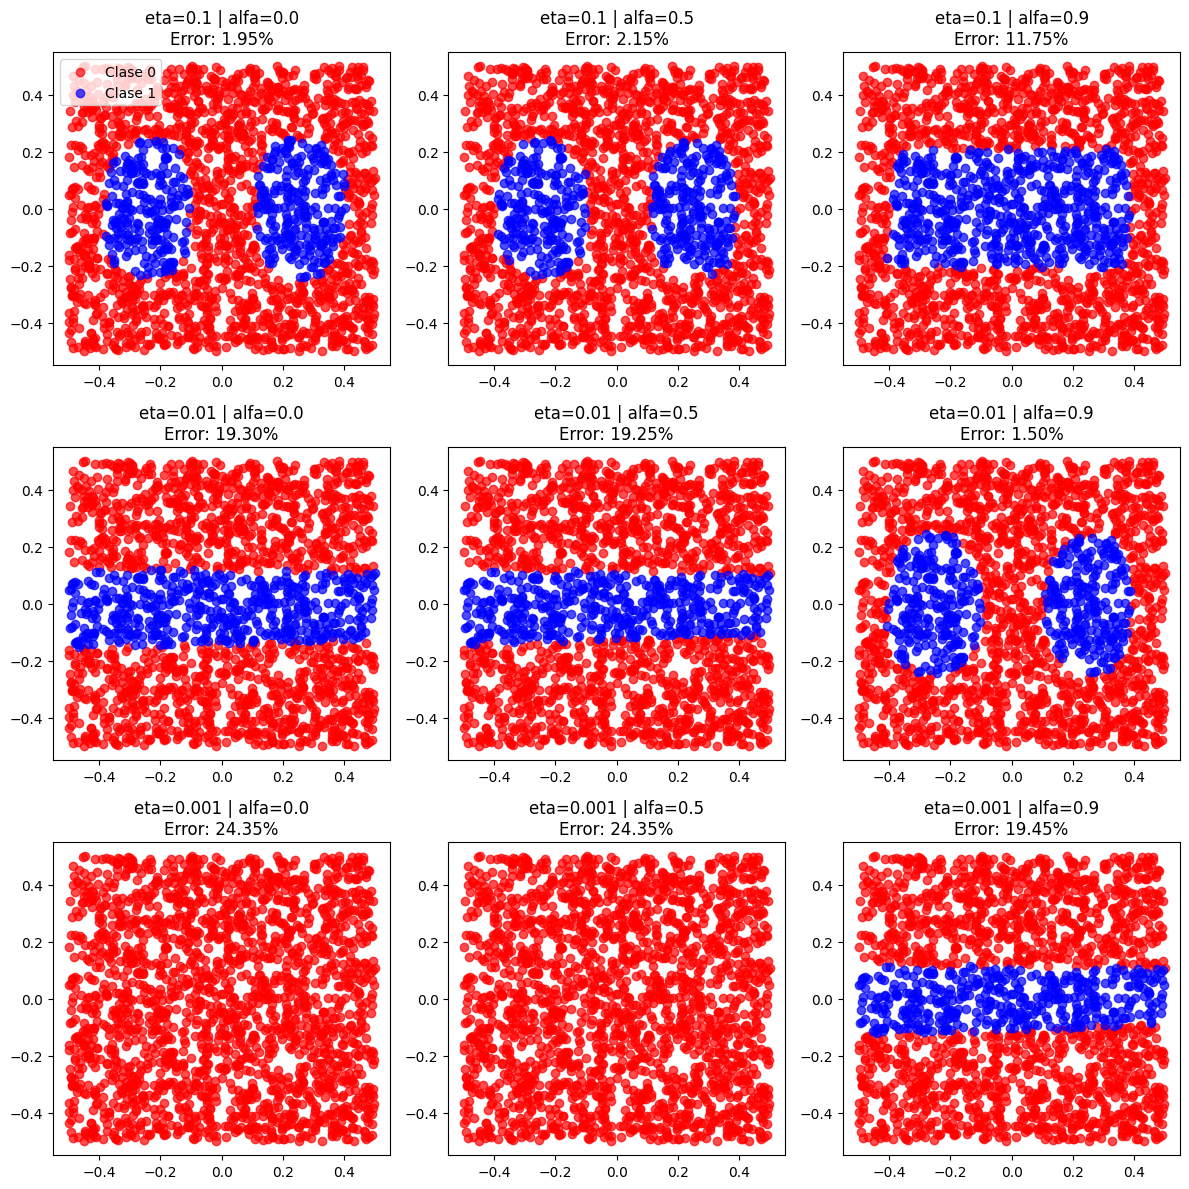

In [31]:
etas = [0.1, 0.01, 0.001]
alfas = [0.0, 0.5, 0.9]

fig, axes = plt.subplots(nrows=len(etas), ncols=len(alfas), 
                         figsize=(4 * len(alfas), 4 * len(etas)), 
                         squeeze=False)

X_test_np = X_test.to_numpy() if hasattr(X_test, 'to_numpy') else X_test

for i, e in enumerate(etas):
    for j, a in enumerate(alfas):
        red = MLPClassifier(
            hidden_layer_sizes=(6,), activation='logistic', solver='sgd', alpha=0.0,
            batch_size=1, learning_rate='constant', learning_rate_init=e,
            momentum=a, nesterovs_momentum=False, tol=0.0, warm_start=True,
            max_iter=50
        )
        
        best_red, *_ = entrenar_red(
            red, 300, X_train, y_train, X_val, y_val, X_test, y_test
        )
        
        y_pred_test = best_red.predict(X_test)
        
        # lo agregamos al eje que va
        ax = axes[i, j]
        
        # filtramos y ploteamos los puntos clase 0
        ax.scatter(X_test_np[y_pred_test == 0, 0], X_test_np[y_pred_test == 0, 1], 
                   color='red', label='Clase 0', alpha=0.7)
        
        # filtramos y ploteamos los puntos clase 1
        ax.scatter(X_test_np[y_pred_test == 1, 0], X_test_np[y_pred_test == 1, 1], 
                   color='blue', label='Clase 1', alpha=0.7)
        
        # mostramos el error en cada gráfico
        error_test = zero_one_loss(y_test, y_pred_test)
        ax.set_title(f'eta={e} | alfa={a}\nError: {error_test:.2%}')
        
        # agg la leyenda solo en el primer gráfico
        if i == 0 and j == 0:
            ax.legend()

plt.tight_layout()
plt.show()


### Análisis de la mejor red
eta 0.01 alfa 0.9 y eta 0.1 alfa 0.5 suelen ser los mejores

# Ejercicio 3. Regularización

# Ejercicio 4. Regularización (2).

# Ejercicio 5. Dimensionalidad.

# (OPCIONAL) Ejercicio 6. Multiclase.

# (OPCIONAL) Ejercicio 7. Minibatch.